In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/raw/breast_cancer.csv")

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

processed_df = pd.DataFrame(X_scaled, columns=X.columns)

processed_df["target"] = y.values

In [7]:
processed_df.to_csv(
    "../data/processed/breast_cancer_processed.csv",
    index=False
)

# Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of features, identify patterns, detect outliers, and analyze relationships between variables before training machine learning models.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Better plot style
sns.set_style("whitegrid")

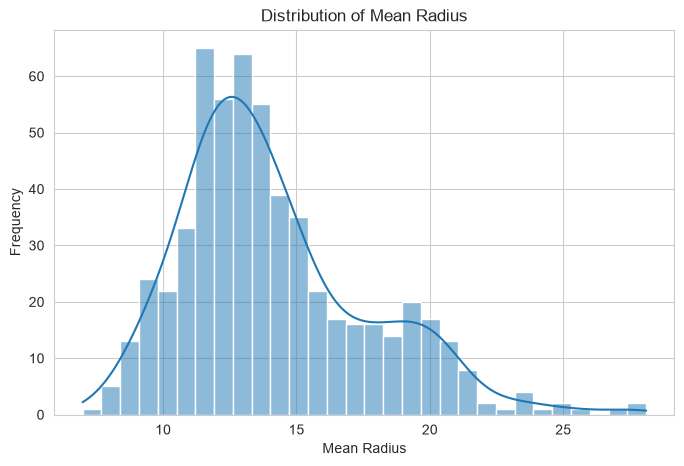

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["mean radius"], bins=30, kde=True)

plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.show()

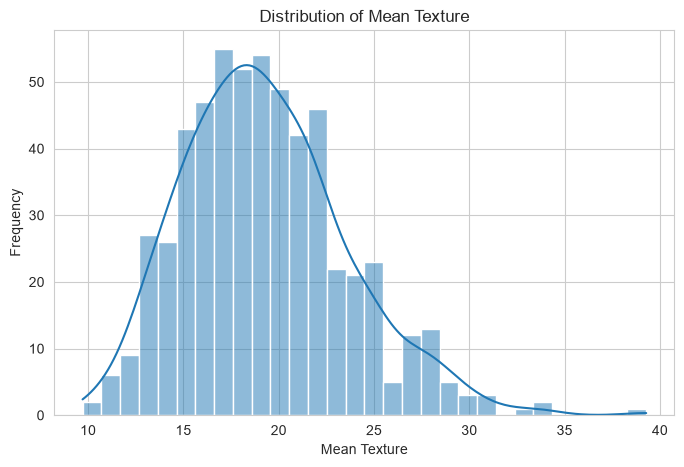

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["mean texture"], bins=30, kde=True)

plt.title("Distribution of Mean Texture")
plt.xlabel("Mean Texture")
plt.ylabel("Frequency")

plt.show()

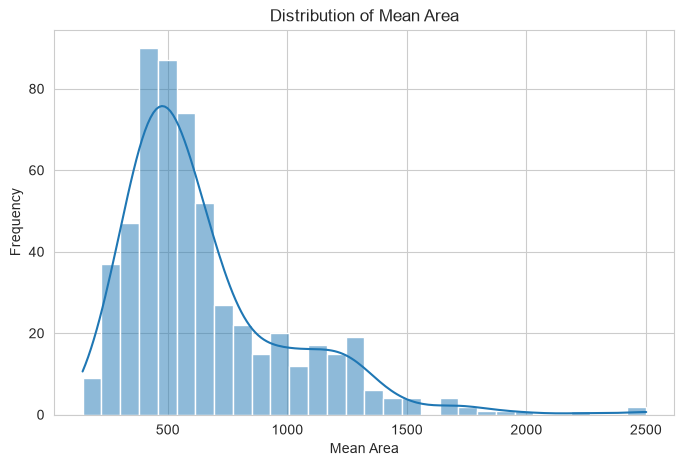

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["mean area"], bins=30, kde=True)

plt.title("Distribution of Mean Area")
plt.xlabel("Mean Area")
plt.ylabel("Frequency")

plt.show()

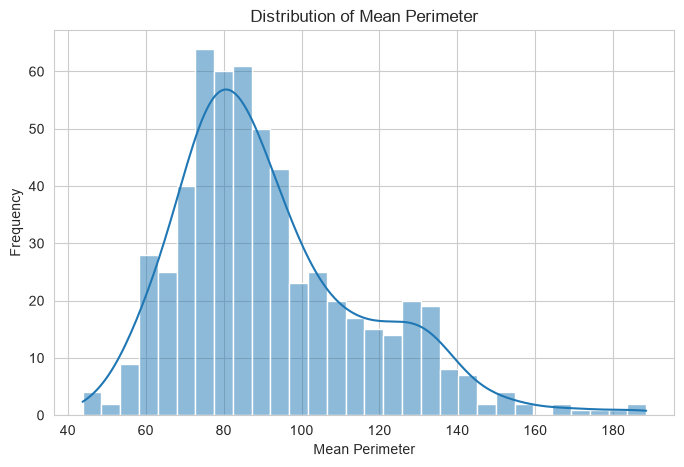

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["mean perimeter"], bins=30, kde=True)

plt.title("Distribution of Mean Perimeter")
plt.xlabel("Mean Perimeter")
plt.ylabel("Frequency")

plt.show()

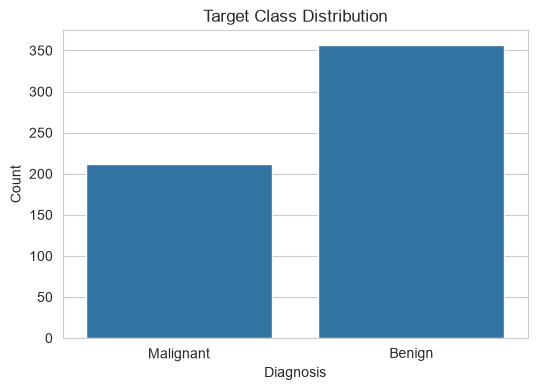

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["target"])

plt.title("Target Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.xticks([0,1], ["Malignant","Benign"])

plt.show()

## Bivariate Analysis

Bivariate analysis helps us understand the relationship between each feature and the target variable (Diagnosis). This allows us to identify which features best separate malignant and benign tumors.

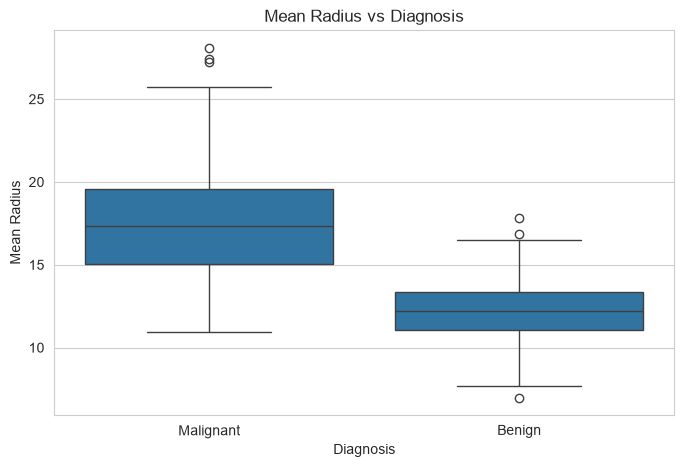

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="mean radius", data=df)

plt.title("Mean Radius vs Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")

plt.xticks([0,1], ["Malignant","Benign"])

plt.show()

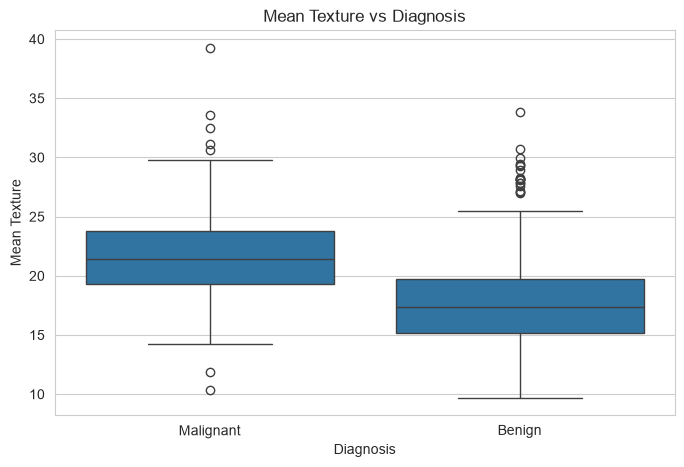

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="mean texture", data=df)

plt.title("Mean Texture vs Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Texture")

plt.xticks([0,1], ["Malignant","Benign"])

plt.show()

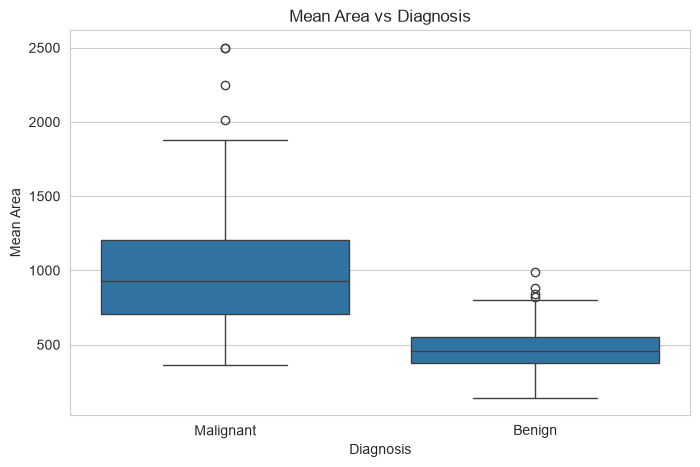

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="mean area", data=df)

plt.title("Mean Area vs Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Area")

plt.xticks([0,1], ["Malignant","Benign"])

plt.show()

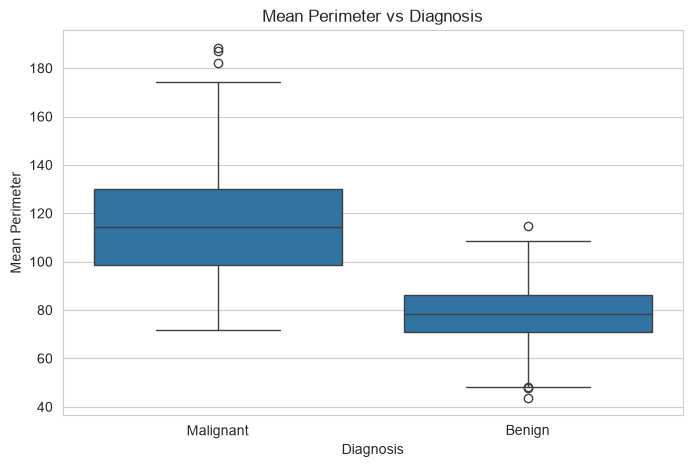

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="mean perimeter", data=df)

plt.title("Mean Perimeter vs Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Perimeter")

plt.xticks([0,1], ["Malignant","Benign"])

plt.show()

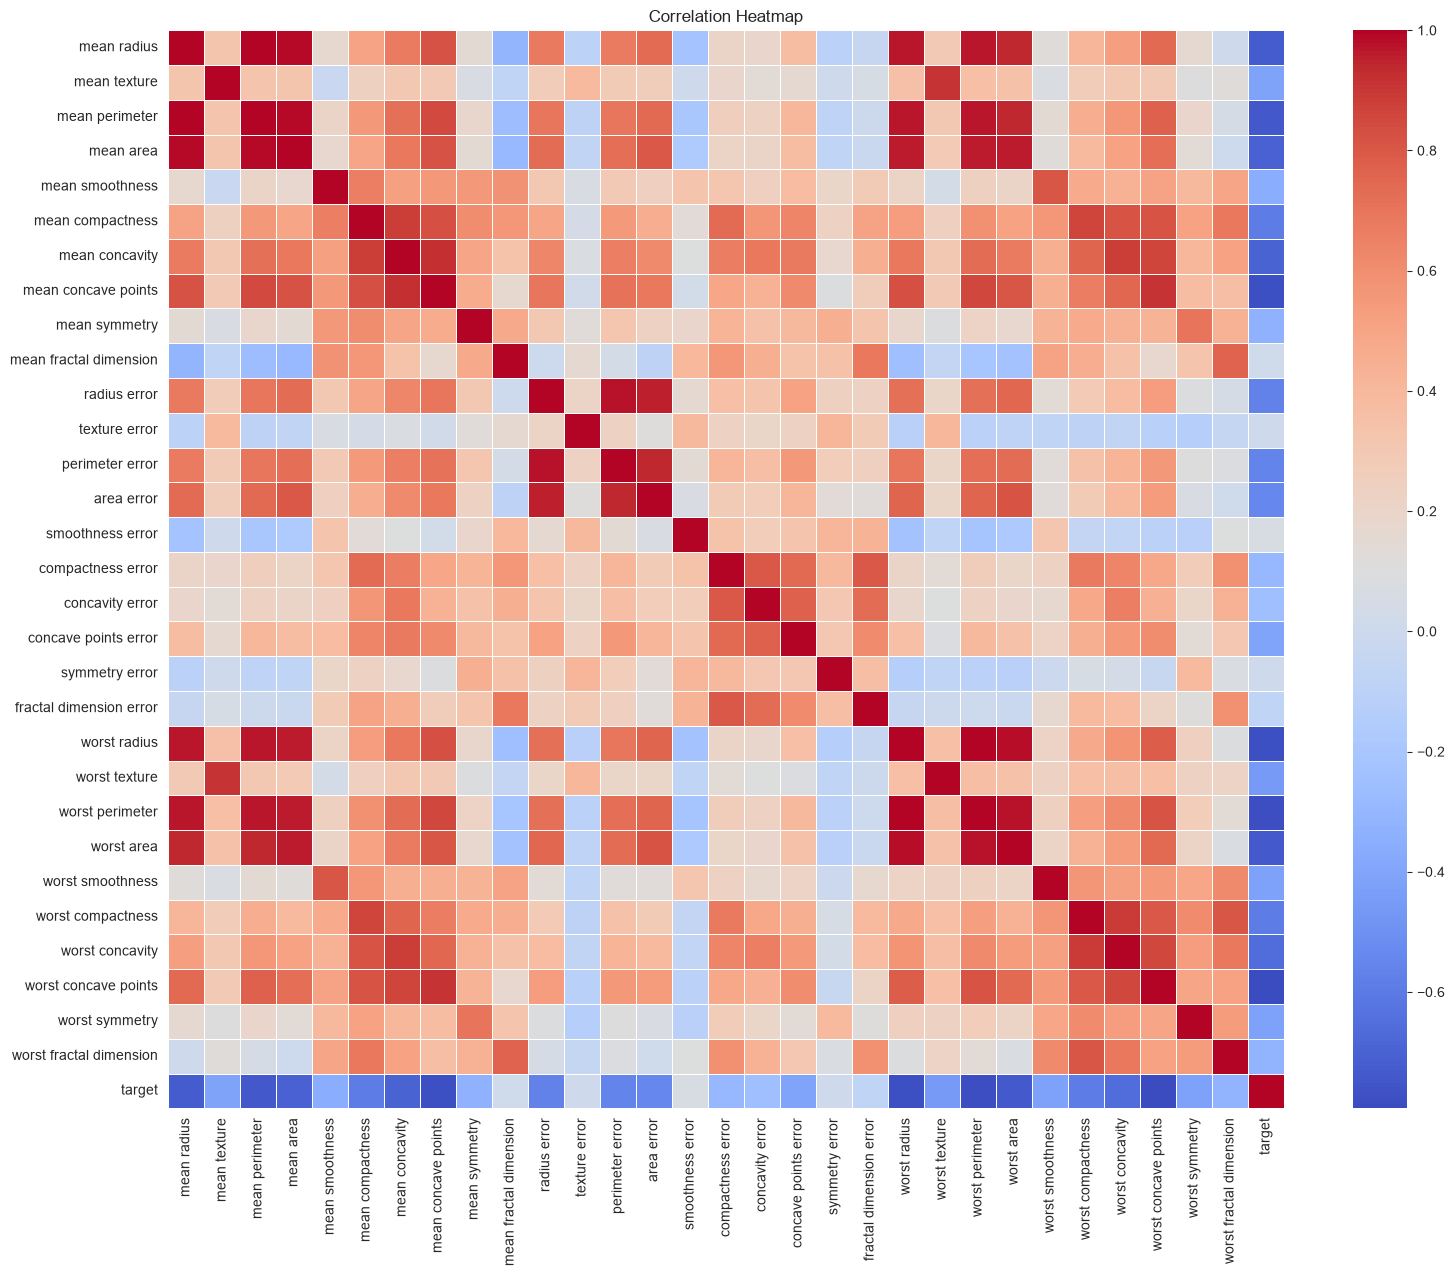

In [18]:
plt.figure(figsize=(18,14))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
correlation_with_target = df.corr()["target"].sort_values(ascending=False)

print(correlation_with_target)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

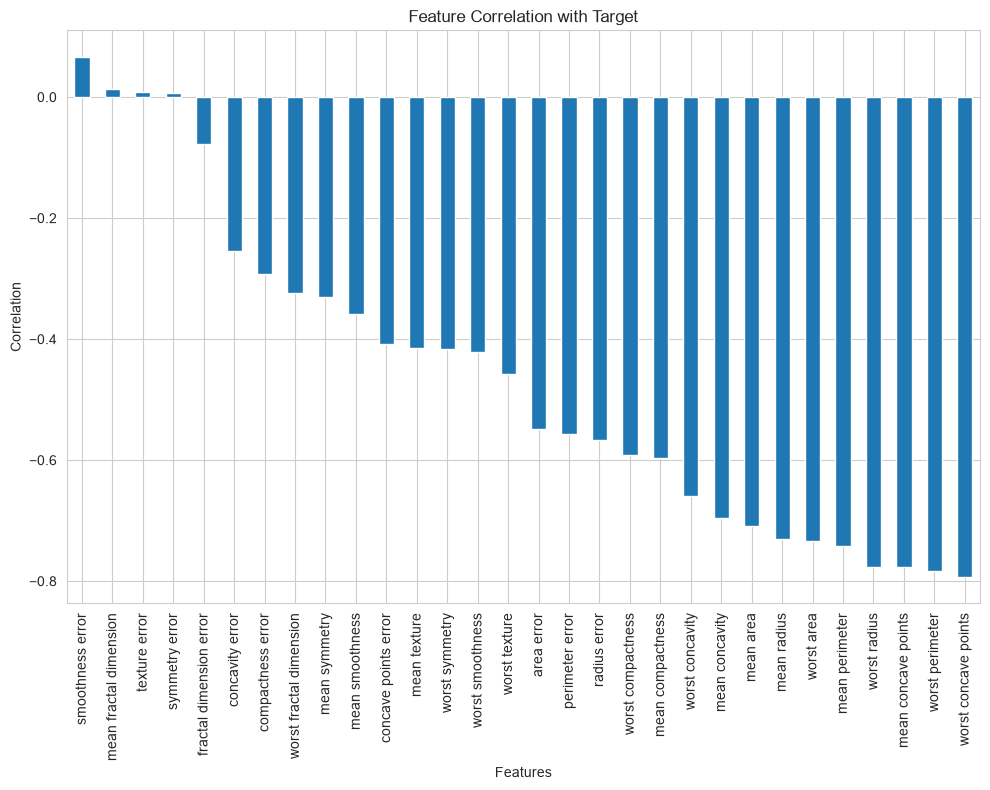

In [20]:
plt.figure(figsize=(10,8))

correlation_with_target.drop("target").plot(kind="bar")

plt.title("Feature Correlation with Target")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.tight_layout()

plt.show()

## EDA Summary

### Key Observations

- Malignant tumors generally have larger radius, perimeter, and area values.
- Several features exhibit strong correlations with the diagnosis.
- The dataset contains highly correlated feature pairs, which is common in medical measurements.
- The distributions suggest that the classes are separable, making the dataset suitable for classification models such as SVM and Decision Tree.